In [1]:
import glob
import json
import os

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from utils import get_data

In [3]:
def viz(ground_truth):
    """
    create a grid visualization of images with color coded bboxes
    args:
    - ground_truth [list[dict]]: ground truth data
    """
    paths = glob.glob('../data/images/*')

    # mapping to access data faster
    gtdic = {}
    for gt in ground_truth:
        gtdic[gt['filename']] = gt

    # color mapping of classes
    colormap = {1: [1, 0, 0], 2: [0, 1, 0], 4: [0, 0, 1]}

    f, ax = plt.subplots(4, 5, figsize=(20, 10))
    for i in range(20):
        x = i % 4
        y = i % 5

        filename = os.path.basename(paths[i])
        img = Image.open(paths[i])
        ax[x, y].imshow(img)

        bboxes = gtdic[filename]['boxes']
        classes = gtdic[filename]['classes']
        for cl, bb in zip(classes, bboxes):
            y1, x1, y2, x2 = bb
            rec = Rectangle((x1, y1), x2- x1, y2-y1, facecolor='none', 
                            edgecolor=colormap[cl])
            ax[x, y].add_patch(rec)
        ax[x ,y].axis('off')
    plt.tight_layout()
    plt.show()

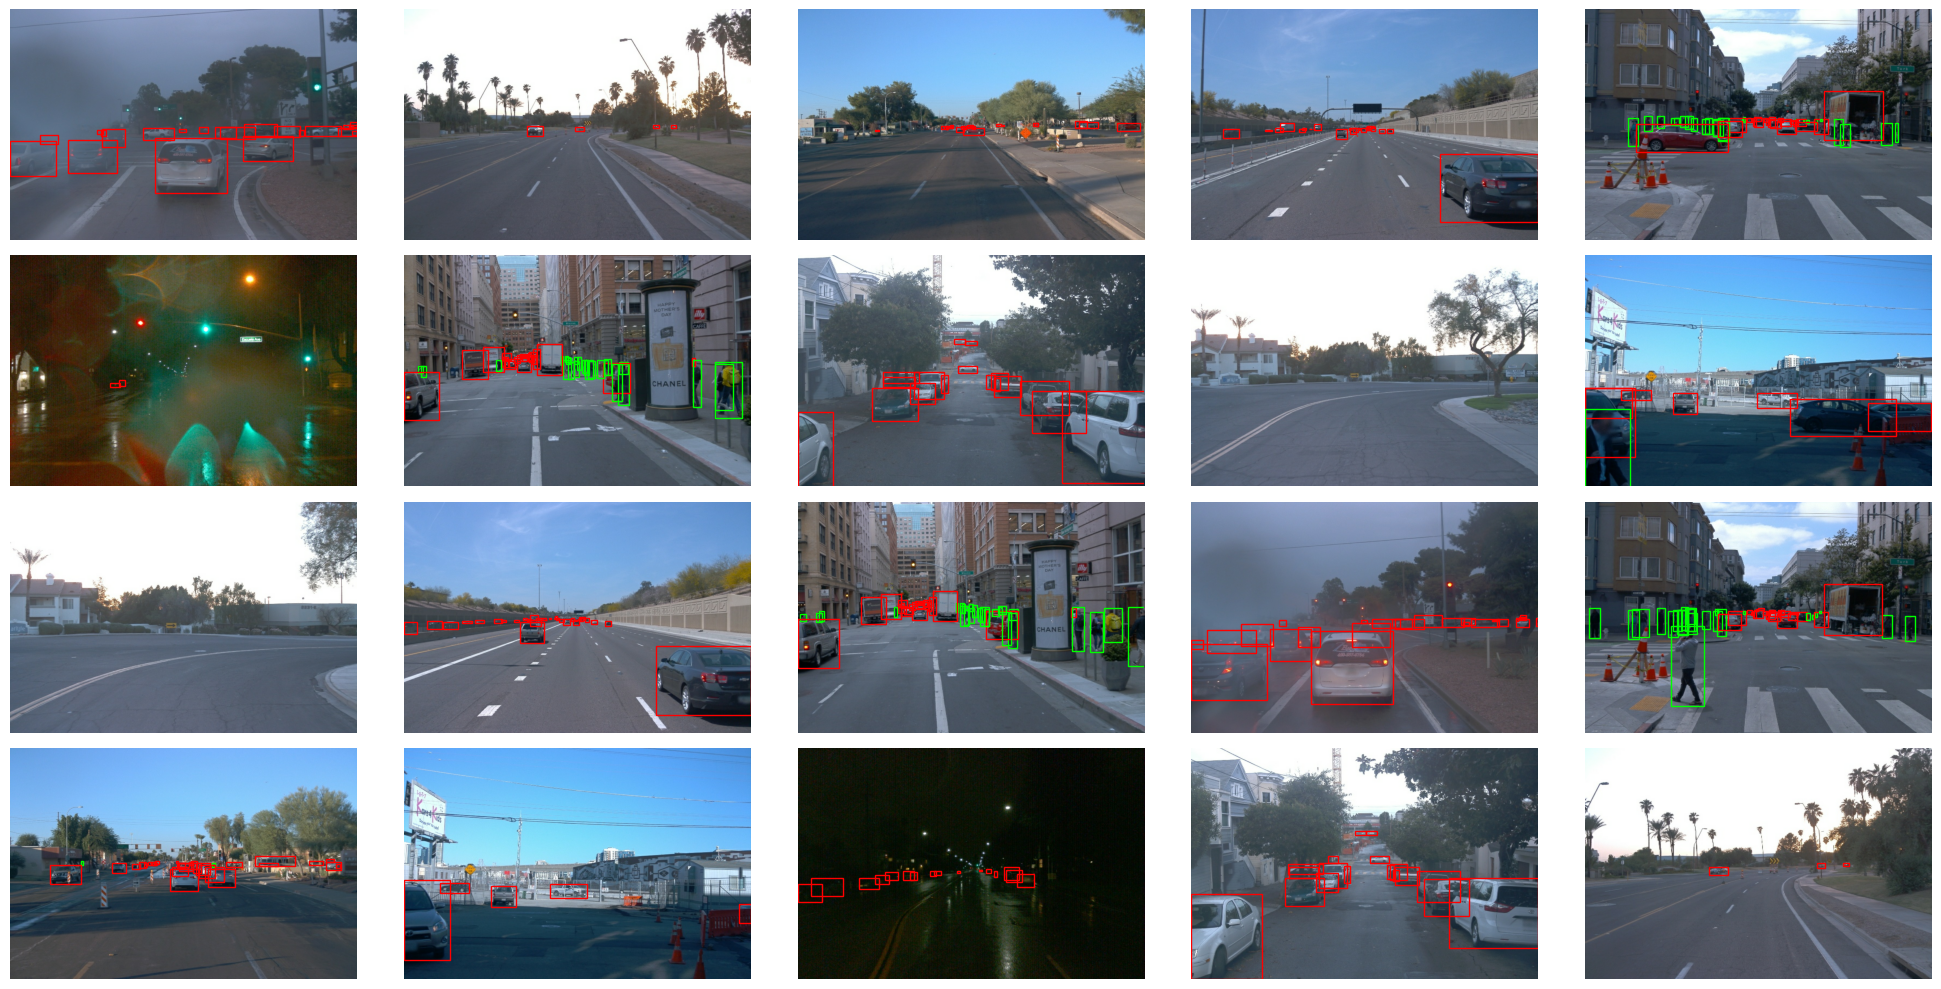

In [4]:
if __name__ == "__main__": 
    ground_truth, _ = get_data()
    viz(ground_truth)